In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats

# 1. Cargar datos
df = pd.read_csv('df_limpio.csv')
datos = df['weight'].dropna()

n = len(datos)
media = datos.mean()
# Dado el Teorema del Límite Central (n > 30), la desviación estándar muestral estima la poblacional
s = datos.std(ddof=1)
se = s / np.sqrt(n)



In [3]:
 # 2. Configuración de intervalos (paleta adaptada para deuteranopía)
config = [
    {
        "conf": 0.99,
        "color": "#E69F00",  # Ámbar / Naranja
        "linestyle": ":",
        "label": "99% Confianza"
    },
    {
        "conf": 0.95,
        "color": "#0072B2",  # Azul estándar
        "linestyle": "--",
        "label": "95% Confianza"
    },
    {
        "conf": 0.90,
        "color": "#CC79A7",  # Magenta / Púrpura rojizo
        "linestyle": "-.",
        "label": "90% Confianza"
    }
]

print("=" * 80)
print(f"RESUMEN ESTADÍSTICO DE 'weight' (n = {n:,})")
print(f"Media (x̄): {media:.4f} | Desviación estándar: {s:.4f} | Error estándar: {se:.4f}")
print("=" * 80)


RESUMEN ESTADÍSTICO DE 'weight' (n = 92,222)
Media (x̄): 624.3231 | Desviación estándar: 1166.4490 | Error estándar: 3.8410


In [4]:
# 3. Cálculo e interpretaciones
intervalos = {}
for item in config:
    conf = item["conf"]
    alpha = 1 - conf
    z = stats.norm.ppf(1 - alpha / 2)
    me = z * se
    lim_inf = media - me
    lim_sup = media + me
    intervalos[conf] = (lim_inf, lim_sup, z, me)

    print(f"\n--- NIVEL DE CONFIANZA DEL {int(conf * 100)}% (α = {alpha:.2f}) ---")
    print(f"Valor crítico z: {z:.4f} | Margen de error: ±{me:.4f}")
    print(f"Intervalo de confianza: [{lim_inf:.4f}, {lim_sup:.4f}]")



--- NIVEL DE CONFIANZA DEL 99% (α = 0.01) ---
Valor crítico z: 2.5758 | Margen de error: ±9.8939
Intervalo de confianza: [614.4292, 634.2169]

--- NIVEL DE CONFIANZA DEL 95% (α = 0.05) ---
Valor crítico z: 1.9600 | Margen de error: ±7.5283
Intervalo de confianza: [616.7948, 631.8514]

--- NIVEL DE CONFIANZA DEL 90% (α = 0.10) ---
Valor crítico z: 1.6449 | Margen de error: ±6.3179
Intervalo de confianza: [618.0051, 630.6410]


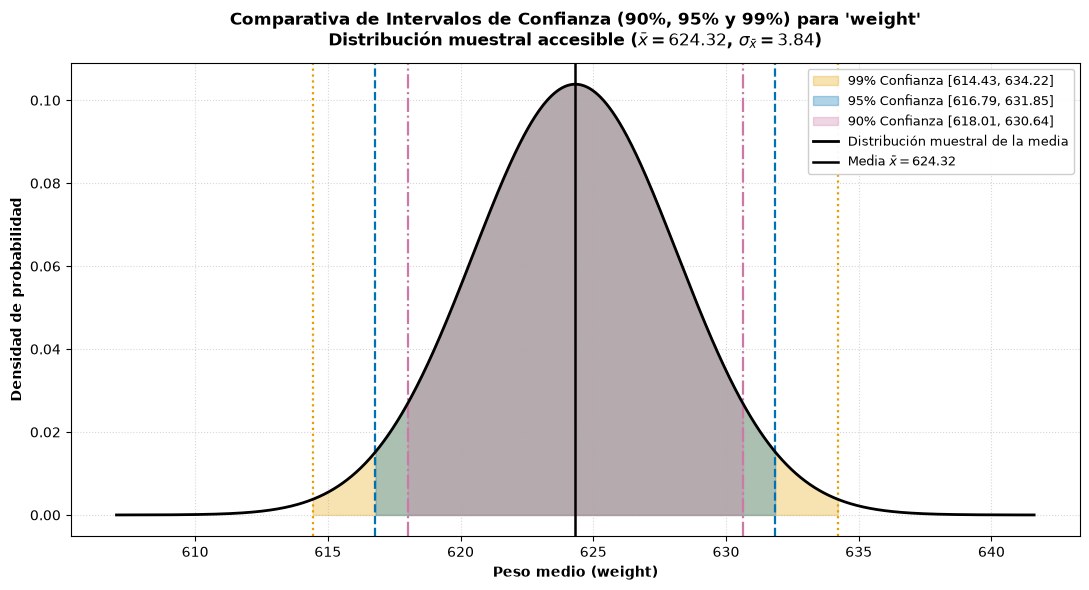

In [5]:
# 4. Gráfica de la distribución muestral
x = np.linspace(media - 4.5 * se, media + 4.5 * se, 1000)
y = stats.norm.pdf(x, media, se)

plt.figure(figsize=(11, 6))

for item in config:
    conf = item["conf"]
    lim_inf, lim_sup, z, me = intervalos[conf]
    
    x_fill = np.linspace(lim_inf, lim_sup, 500)
    y_fill = stats.norm.pdf(x_fill, media, se)
    
    label_text = f"{item['label']} [{lim_inf:.2f}, {lim_sup:.2f}]"
    plt.fill_between(x_fill, y_fill, color=item["color"], alpha=0.30, label=label_text)
    plt.axvline(lim_inf, color=item["color"], linestyle=item["linestyle"], lw=1.6)
    plt.axvline(lim_sup, color=item["color"], linestyle=item["linestyle"], lw=1.6)

plt.plot(x, y, color="#000000", lw=2, label="Distribución muestral de la media")
plt.axvline(media, color="#000000", linestyle="-", lw=1.8, label=f"Media $\\bar{{x}} = {media:.2f}$")

plt.title("Comparativa de Intervalos de Confianza (90%, 95% y 99%) para 'weight'\n"
          rf"Distribución muestral accesible ($\bar{{x}} = {media:.2f}$, $\sigma_{{\bar{{x}}}} = {se:.2f}$)",
          fontsize=12, fontweight="bold", pad=12)
plt.xlabel("Peso medio (weight)", fontsize=10, fontweight="bold")
plt.ylabel("Densidad de probabilidad", fontsize=10, fontweight="bold")
plt.legend(loc="upper right", framealpha=0.95, fontsize=9)
plt.grid(True, linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()